In [3]:
def noteToFreq(note):
    a = 440 #frequency of A (coomon value is 440Hz)
    return (a / 32) * (2 ** ((note - 9) / 12))

### Replicating Note segmentation

In [57]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def filter_vocal_contour(pitch_contour, bark_energies):
    """
    Filters pitch contour to retain only vocal segments.
    pitch_contour: 1D array of f0 values (Hz)
    bark_energies: 2D array (frames x 12 bark bands)
    """
    # Identify melody vs non-melody frames (voiced initial guess)
    voiced_idx = pitch_contour > 0
    unvoiced_idx = pitch_contour <= 0
    
    # Fit Gaussian distributions to Bark energy features [cite: 128, 129]
    mu_vocal = np.mean(bark_energies[voiced_idx], axis=0)
    cov_vocal = np.cov(bark_energies[voiced_idx], rowvar=False)
    
    # Simple likelihood-based classification [cite: 131, 132]
    # (Simplified: in practice, use scipy.stats.multivariate_normal)
    vocal_mask = (pitch_contour > 0) 
    
    # Apply a 1-second binary moving average to smooth the prediction [cite: 132]
    smoothed_mask = gaussian_filter1d(vocal_mask.astype(float), sigma=50) > 0.5
    
    # Eliminate contours entirely outside vocal regions [cite: 134]
    filtered_contour = pitch_contour.copy()
    filtered_contour[~smoothed_mask] = 0
    return filtered_contour

In [61]:
import numpy as np
import pandas as pd

f0_contour = pd.read_csv(paired_data['05']['autogt'], names = ['timestamp', 'freq'])

bark_bands = pd.read_csv("../data/cante2midi_bakbands/05_Antonio Mairena_Verguenza.barkbands.csv",
                         sep=" ",
                         names= [0.0, 50.0, 100.0, 150.0, 200.0, 300.0, 400.0, 510.0, 630.0, 770.0, 920.0, 1080.0, 1270.0, 1480.0, 1720.0, 2000.0, 2320.0, 2700.0, 3150.0, 3700.0, 4400.0, 5300.0, 6400.0, 7700.0, 9500.0, 12000.0, 15500.0, 20500.0, 27000.0])

vocal_contour = filter_vocal_contour(f0_contour['freq'], bark_energies=bark_bands[bark_bands.columns[:12]])

/tmp/ipykernel_26650/1387048557.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mu_vocal = np.mean(bark_energies[voiced_idx], axis=0)
/tmp/ipykernel_26650/1387048557.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cov_vocal = np.cov(bark_energies[voiced_idx], rowvar=False)


In [66]:
f0_contour['vocal_contour'] = vocal_contour

In [68]:
f0_contour[f0_contour['vocal_contour']!=0]

,timestamp,freq,vocal_contour
178,0.539864,251.258,251.258
179,0.542766,255.650,255.650
180,0.545669,263.141,263.141
181,0.548571,264.665,264.665
182,0.551474,267.741,267.741
...,...,...,...
35378,102.707664,353.286,353.286
35379,102.710567,357.391,357.391
35380,102.713469,361.544,361.544
35381,102.716372,365.745,365.745


In [ ]:
def get_note_onsets(pitch_cents, rms_values, fs_hop=128/44100):
    onsets = []
    
    # 1. Gaussian Derivative Filtering [cite: 152]
    # sigma=43.5ms to cover slow vibrato (4Hz) [cite: 155]
    sigma_samples = 0.0435 / fs_hop
    # h[n] is the first derivative of Gaussian [cite: 152]
    filtered_pitch = gaussian_filter1d(pitch_cents, sigma=sigma_samples, order=1)
    gd_onsets = np.where(np.abs(filtered_pitch) > 4.0)[0] # Threshold 4.0 [cite: 158]
    onsets.extend(gd_onsets)

    # 2. Local RMS Fluctuations [cite: 164]
    # Compare sample to surrounding 150ms mean [cite: 164]
    window = int(0.150 / fs_hop)
    rms_mean = gaussian_filter1d(rms_values, sigma=window/2)
    r_loc = 20 * np.log10(rms_values / (rms_mean + 1e-6))
    vol_onsets = np.where(r_loc < -10)[0] # Threshold -10dB [cite: 164]
    onsets.extend(vol_onsets)

    # 3. Pitch Dips (z-score) [cite: 173]
    z_scores = (pitch_cents - np.mean(pitch_cents)) / np.std(pitch_cents)
    dip_onsets = np.where(z_scores < -2)[0] # Threshold z < -2 [cite: 175]
    onsets.extend(dip_onsets)

    return sorted(list(set(onsets)))

In [ ]:




pesto_results_05 = pd.read_csv(paired_data['05']={
    'timestamp':paired_data['05']['PESTO']['timesteps'],
    'timesteps': paired_data['05']['PESTO']['timesteps']/1000,
    'freq': paired_data['05']['PESTO']['pitch'],
    'confidence':paired_data['05']['PESTO']['confidence']
})
pesto_results_05.head()

r

threshold = 0.5  # choose your threshold

# 1. Voicing boolean
pesto_results_05["voicing"] = pesto_results_05["confidence"] > threshold

# 2. Detect start of new voiced segment
start_segment = pesto_results_05["voicing"] & (~pesto_results_05["voicing"].shift(fill_value=False))

# 3. Assign segment numbers
pesto_results_05["voice_segment"] = start_segment.cumsum()

# 4. Set NaN where not voiced
pesto_results_05.loc[~pesto_results_05["voicing"], "voice_segment"] = np.nan

pesto_results_05["voice_segment"] = pesto_results_05["voice_segment"].astype("Int64")


f_ref = 440.0
pesto_results_05["cents"] = np.nan
mask = pesto_results_05["voicing"]
pesto_results_05.loc[mask, "cents"] = 1200 * np.log2(pesto_results_05.loc[mask, "freq"] / f_ref)


pesto_results_05.head()

,timestamp,timesteps,freq,confidence,voicing,voice_segment,cents
0,0.0,0.00,0.0,0.098939,False,<NA>,NaN
1,10.0,0.01,0.0,0.100373,False,<NA>,NaN
2,20.0,0.02,0.0,0.088221,False,<NA>,NaN
3,30.0,0.03,0.0,0.099691,False,<NA>,NaN
4,40.0,0.04,0.0,0.098981,False,<NA>,NaN


In [35]:
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

def upper_envelope(y):
    y = np.asarray(y)
    
    # find peaks
    peaks, _ = find_peaks(y)
    
    # include endpoints to avoid NaNs at edges
    peaks = np.concatenate(([0], peaks, [len(y)-1]))
    
    x = np.arange(len(y))
    
    # interpolate envelope
    interp = interp1d(peaks, y[peaks], kind="linear", fill_value="extrapolate")
    
    return interp(x)

pesto_results_05["upper_env"] = np.nan

for seg, g in pesto_results_05[pesto_results_05["voicing"]].groupby("voice_segment"):
    env = upper_envelope(g["cents"].values)
    pesto_results_05.loc[g.index, "upper_env"] = env

/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in d

In [38]:
pesto_results_05[pesto_results_05['voice_segment']==3]

,timestamp,timesteps,freq,confidence,voicing,voice_segment,cents,upper_env
2271,22710.0,22.709999,322.497528,0.597790,True,3,-537.858582,-537.858582
2272,22720.0,22.719999,317.188141,0.953417,True,3,-566.597656,-520.626247
2273,22730.0,22.730000,323.341614,0.995638,True,3,-533.333252,-503.393913
2274,22740.0,22.740000,328.640717,0.998753,True,3,-505.190826,-486.161579
2275,22750.0,22.750000,336.035767,0.999640,True,3,-466.666473,-468.929245
2276,22760.0,22.760000,342.568451,0.999998,True,3,-433.333527,-451.696911
2277,22770.0,22.770000,342.568451,1.000000,True,3,-433.333527,-434.464577
2278,22780.0,22.780001,342.568451,1.000000,True,3,-433.333527,-417.232243
2279,22790.0,22.790001,349.228241,1.000000,True,3,-399.999908,-399.999908
2280,22800.0,22.799999,342.568451,1.000000,True,3,-433.333527,-407.142768


In [39]:
import matplotlib.pyplot as plt

def plot_segment_envelope(df, segment_id, time_col="timestamp"):
    """
    Plot cents contour and upper envelope for a given voiced segment.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing 'cents', 'upper_env', and 'voice_segment'.
    segment_id : int
        Segment number to visualize.
    time_col : str
        Column to use for the x-axis (default 'timestamp').
    """
    
    seg = df[df["voice_segment"] == segment_id]

    if seg.empty:
        print(f"Segment {segment_id} not found.")
        return

    x = seg[time_col]
    y = seg["cents"]
    env = seg["upper_env"]

    plt.figure(figsize=(10,4))
    plt.plot(x, y, label="Cents contour", alpha=0.7)
    plt.plot(x, env, label="Upper envelope", linewidth=2)

    plt.xlabel("Time")
    plt.ylabel("Cents (relative to 440 Hz)")
    plt.title(f"Voice Segment {segment_id}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

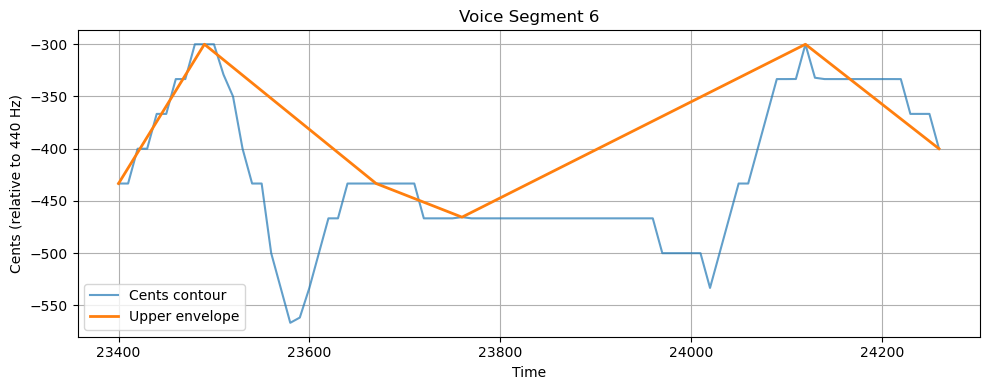

In [41]:
plot_segment_envelope(pesto_results_05, segment_id=6)